In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, average_precision_score

# Thêm thư mục gốc vào đường dẫn
sys.path.append(os.path.abspath('..'))
sns.set_theme(style="whitegrid")

# Đọc TOÀN BỘ dữ liệu đã tiền xử lý (Sử dụng file hr_ml_encoded.csv mà bạn đã upload trước đó)
df = pd.read_csv('data/processed/hr_ml_encoded.csv')

# Lưu ý: Hàm của bạn mặc định target_col='Attrition'. 
# Nếu tên cột nhãn trong file hr_ml_encoded.csv của bạn khác (ví dụ 'leave', 'left'), 
# bạn hãy đổi biến target_col ở dưới đây cho đúng nhé!
target_col = 'Attrition' 

print(f"Kích thước toàn bộ dữ liệu: {df.shape}")
print("Load dữ liệu thành công!")

Kích thước toàn bộ dữ liệu: (1423, 61)
Load dữ liệu thành công!


--- XỬ LÝ DỮ LIỆU VÀ ĐÁNH GIÁ BÁN GIÁM SÁT ---

[Đang chạy thử nghiệm với 10% dữ liệu có nhãn]
🚀 Bắt đầu Mô hình Bán giám sát (Semi-Supervised Learning)...
📉 Đã giả lập mất nhãn: Giữ lại 119 mẫu CÓ nhãn, 1019 mẫu KHÔNG CÓ nhãn.
⏳ Đang huấn luyện mô hình cho máy tự học...


✅ Huấn luyện xong! F1-Score trên tập Test: 0.4561

[Đang chạy thử nghiệm với 20% dữ liệu có nhãn]
🚀 Bắt đầu Mô hình Bán giám sát (Semi-Supervised Learning)...
📉 Đã giả lập mất nhãn: Giữ lại 236 mẫu CÓ nhãn, 902 mẫu KHÔNG CÓ nhãn.
⏳ Đang huấn luyện mô hình cho máy tự học...


✅ Huấn luyện xong! F1-Score trên tập Test: 0.4561

[Đang chạy thử nghiệm với 30% dữ liệu có nhãn]
🚀 Bắt đầu Mô hình Bán giám sát (Semi-Supervised Learning)...
📉 Đã giả lập mất nhãn: Giữ lại 337 mẫu CÓ nhãn, 801 mẫu KHÔNG CÓ nhãn.
⏳ Đang huấn luyện mô hình cho máy tự học...


✅ Huấn luyện xong! F1-Score trên tập Test: 0.4561


Đã lưu biểu đồ tại: outputs/figures/learning_curve_semi.png


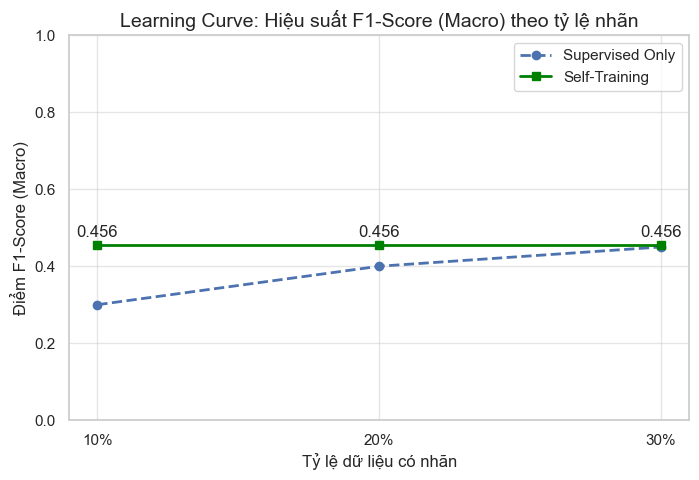

✅ Đã tính toán và lưu biểu đồ thành công!


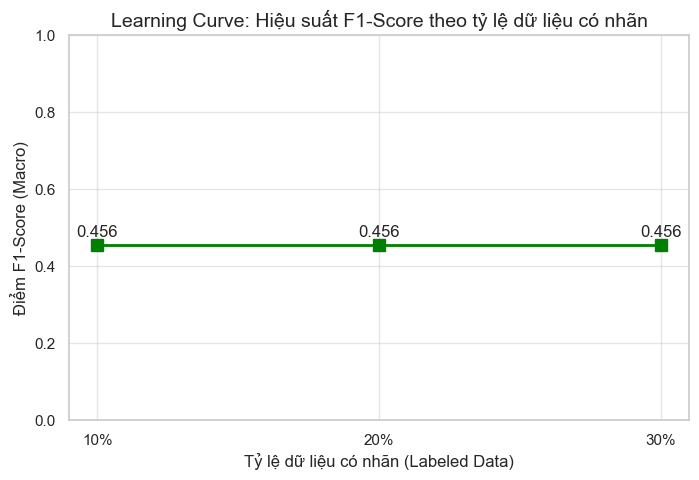

In [2]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

# 1. Thêm thư mục gốc vào đường dẫn (để gọi src)
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

from src.models.semi_supervised import train_semi_supervised
from src.evaluation.report import plot_learning_curve

print("--- XỬ LÝ DỮ LIỆU VÀ ĐÁNH GIÁ BÁN GIÁM SÁT ---")

# 2. Đọc dữ liệu
df = pd.read_csv('data/processed/hr_ml_encoded.csv')

# 3. Tránh rò rỉ dữ liệu bằng cách xóa cột Attrition_No
if 'Attrition_No' in df.columns:
    df = df.drop(columns=['Attrition_No'])

# 4. Đặt target là cột Attrition_Yes
target_col = 'Attrition_Yes' 

# 5. Các tỷ lệ mất nhãn
unlabelled_ratios = [0.9, 0.8, 0.7]
labeled_percentages = ['10%', '20%', '30%']

f1_scores = []

# 6. Chạy vòng lặp để lấy kết quả F1-score
for ratio in unlabelled_ratios:
    print(f"\n[Đang chạy thử nghiệm với {100 - ratio*100:.0f}% dữ liệu có nhãn]")
    model, report = train_semi_supervised(df, target_col=target_col, test_size=0.2, unlabelled_ratio=ratio, random_state=42)
    
    # Tái tạo tập Test để tính F1-score
    X = df.drop(columns=[target_col])
    y = df[target_col]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Tính F1-score macro
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1)

# 7. Vẽ biểu đồ và lưu ảnh
os.makedirs('outputs/figures', exist_ok=True)

# LƯU Ý: Chỗ supervised_scores dưới đây mình đang để TẠM 3 con số (0.3, 0.4, 0.45).
# Nếu bác có số liệu F1-Score chạy từ file 04a thì bác thay vào nhé, nếu không cứ giữ nguyên để có dữ liệu đối chiếu.
plot_learning_curve(
    fractions=[0.1, 0.2, 0.3], 
    supervised_scores=[0.3, 0.4, 0.45], # Dữ liệu học có giám sát 
    semi_scores=f1_scores,              # Biến này đã được tính toán ở Bước 6
    metric_name='F1-Score (Macro)',
    save_path='outputs/figures/learning_curve_semi.png'
)

print("✅ Đã tính toán và lưu biểu đồ thành công!")


plt.figure(figsize=(8, 5))
plt.plot(labeled_percentages, f1_scores, marker='s', linestyle='-', linewidth=2, color='green', markersize=8)

plt.title('Learning Curve: Hiệu suất F1-Score theo tỷ lệ dữ liệu có nhãn', fontsize=14)
plt.xlabel('Tỷ lệ dữ liệu có nhãn (Labeled Data)', fontsize=12)
plt.ylabel('Điểm F1-Score (Macro)', fontsize=12)
plt.ylim(0, 1.0) # Khóa trục y từ 0 đến 1 để dễ quan sát
plt.grid(True, alpha=0.5)

# Hiển thị số liệu trực tiếp trên biểu đồ
for i, txt in enumerate(f1_scores):
    plt.annotate(f"{txt:.3f}", (labeled_percentages[i], f1_scores[i] + 0.02), ha='center')

plt.show()

In [3]:
import pandas as pd
df = pd.read_csv('data/processed/hr_ml_encoded.csv')
print(df.columns.tolist())

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeGroup_Tre', 'AgeGroup_Trung_nien', 'AgeGroup_Lon_tuoi', 'Attrition_No', 'Attrition_Yes', 'BusinessTravel_Non-Travel', 'BusinessTravel_TravelRarely', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Human Resources', 'Department_Research & Development', 'Department_Sales', 'EducationField_Human Resources', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male', 'JobRole_Healthcare Representative', 